# Week 1: Strategic Planning and Data Exploration in Logistics
### Multi-Carrier Last-Mile Delivery Analytics & Predictive Modeling Framework
* **Role**: Logistics Data Analyst Intern
* **Dataset**: `Delivery_Logistics.csv` (25,000 shipment dispatches)
* **Scope**: Strategic Planning, Exploratory Data Analysis, Logistics KPIs Computation, Machine Learning Prototyping (Delay Classification, Cost Modeling, Carrier Clustering), and Visualizations.


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, mean_squared_error, r2_score

# Visual aesthetics
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['figure.dpi'] = 150
%matplotlib inline

print('All packages imported successfully.')


All packages imported successfully.


## Stage 1: Data Ingestion & Quality Audit
We load `Delivery_Logistics.csv` containing 25,000 shipment dispatches across 9 3PL partners, 6 vehicle classes, 4 delivery modes, and 5 regions.


In [3]:
df = pd.read_csv('Delivery_Logistics.csv')

print(f'Total Records Ingested: {len(df):,}')
print(f'Total Features / Columns: {df.shape[1]}')
print('\nDataset Schema & Missing Values:')
missing_df = pd.DataFrame({
    'Data Type': df.dtypes,
    'Missing Count': df.isnull().sum(),
    'Missing %': (df.isnull().sum() / len(df)) * 100,
    'Unique Values': df.nunique()
})
display(missing_df)

display(df.head())


Total Records Ingested: 25,000
Total Features / Columns: 15

Dataset Schema & Missing Values:


,Data Type,Missing Count,Missing %,Unique Values
delivery_id,float64,0,0.0,24502
delivery_partner,str,0,0.0,9
package_type,str,0,0.0,9
vehicle_type,str,0,0.0,6
delivery_mode,str,0,0.0,4
region,str,0,0.0,5
weather_condition,str,0,0.0,6
distance_km,float64,0,0.0,2935
package_weight_kg,float64,0,0.0,4853
delivery_time_hours,str,0,0.0,1


,delivery_id,delivery_partner,package_type,vehicle_type,delivery_mode,region,weather_condition,distance_km,package_weight_kg,delivery_time_hours,expected_time_hours,delayed,delivery_status,delivery_rating,delivery_cost
0,250.99,delhivery,automobile parts,bike,same day,west,clear,297.0,46.96,00:00.0,00:00.0,no,delivered,3,1632.7206
1,250.99,xpressbees,cosmetics,ev van,express,central,cold,89.6,47.39,00:00.0,00:00.0,no,delivered,5,640.1700
2,250.99,shadowfax,groceries,truck,two day,east,rainy,273.5,26.89,00:00.0,00:00.0,no,delivered,4,1448.1700
3,250.99,dhl,electronics,ev van,same day,east,cold,269.7,12.69,00:00.0,00:00.0,no,delivered,3,1486.5700
4,250.99,dhl,clothing,van,two day,north,foggy,256.7,37.02,00:00.0,00:00.0,no,delivered,4,1394.5600


## Stage 2: Core Logistics Key Performance Indicators (KPIs)
We compute the primary operational metrics:
- **On-Time Delivery Rate (OTDR)**
- **Shipment Delay Rate**
- **Shipment Failure Rate (SFR)**
- **Average Delivery Cost & Cost per Kilometer (CPK)**
- **Customer Satisfaction (CSAT / Delivery Rating)**


In [4]:
total_orders = len(df)
status_counts = df['delivery_status'].value_counts()

on_time_count = status_counts.get('delivered', 0)
delayed_count = status_counts.get('delayed', 0)
failed_count = status_counts.get('failed', 0)

otdr = (on_time_count / total_orders) * 100
delay_rate = (delayed_count / total_orders) * 100
failure_rate = (failed_count / total_orders) * 100

avg_cost = df['delivery_cost'].mean()
total_cost = df['delivery_cost'].sum()
total_distance = df['distance_km'].sum()
cost_per_km = total_cost / total_distance

mean_rating = df['delivery_rating'].mean()
rating_by_status = df.groupby('delivery_status')['delivery_rating'].mean().to_dict()

kpi_summary = pd.DataFrame([
    {'Metric': 'Total Orders Dispatched', 'Value': f'{total_orders:,}', 'Unit': 'Shipments'},
    {'Metric': 'On-Time Delivery Rate (OTDR)', 'Value': f'{otdr:.2f}%', 'Unit': 'Percentage'},
    {'Metric': 'Overall Delay Rate', 'Value': f'{delay_rate:.2f}%', 'Unit': 'Percentage'},
    {'Metric': 'Shipment Failure Rate (SFR)', 'Value': f'{failure_rate:.2f}%', 'Unit': 'Percentage'},
    {'Metric': 'Average Delivery Cost', 'Value': f'₹{avg_cost:.2f}', 'Unit': 'INR per Shipment'},
    {'Metric': 'Cost per Kilometer (CPK)', 'Value': f'₹{cost_per_km:.2f}', 'Unit': 'INR per KM'},
    {'Metric': 'Overall Customer Rating (CSAT)', 'Value': f'{mean_rating:.2f} ★', 'Unit': '1-5 Stars'},
    {'Metric': 'CSAT: Delivered On-Time', 'Value': f"{rating_by_status.get('delivered', 0):.2f} ★", 'Unit': '1-5 Stars'},
    {'Metric': 'CSAT: Delayed Orders', 'Value': f"{rating_by_status.get('delayed', 0):.2f} ★", 'Unit': '1-5 Stars'},
    {'Metric': 'CSAT: Failed Orders', 'Value': f"{rating_by_status.get('failed', 0):.2f} ★", 'Unit': '1-5 Stars'},
])

display(kpi_summary)


,Metric,Value,Unit
0,Total Orders Dispatched,"25,000",Shipments
1,On-Time Delivery Rate (OTDR),73.32%,Percentage
2,Overall Delay Rate,21.36%,Percentage
3,Shipment Failure Rate (SFR),5.31%,Percentage
4,Average Delivery Cost,₹864.94,INR per Shipment
5,Cost per Kilometer (CPK),₹5.75,INR per KM
6,Overall Customer Rating (CSAT),3.67 ★,1-5 Stars
7,CSAT: Delivered On-Time,4.21 ★,1-5 Stars
8,CSAT: Delayed Orders,2.40 ★,1-5 Stars
9,CSAT: Failed Orders,1.31 ★,1-5 Stars


## Stage 3: Multi-Dimensional Driver & Segmentation Analysis
Cross-tabulating fulfillment performance across:
1. **3PL Carrier Partners**
2. **Delivery Service Modes** (Express, Same Day, Two Day, Standard)
3. **Prevailing Weather Conditions**
4. **Vehicle Types & Fleet Electrification**


In [5]:
# 1. Carrier Benchmark
partner_stats = df.groupby('delivery_partner').agg(
    total_orders=('delivery_id', 'count'),
    delay_rate=('delayed', lambda x: (x == 'yes').mean() * 100),
    failure_rate=('delivery_status', lambda x: (x == 'failed').mean() * 100),
    avg_cost=('delivery_cost', 'mean'),
    cost_per_km=('delivery_cost', 'sum'),
    total_dist=('distance_km', 'sum'),
    avg_rating=('delivery_rating', 'mean')
)
partner_stats['cost_per_km'] = partner_stats['cost_per_km'] / partner_stats['total_dist']
partner_stats = partner_stats.sort_values(by='delay_rate')
print('=== 3PL Carrier Performance Benchmark ===')
display(partner_stats[['total_orders', 'delay_rate', 'failure_rate', 'avg_cost', 'cost_per_km', 'avg_rating']])

# 2. Delivery Mode Impact
mode_stats = df.groupby('delivery_mode').agg(
    total_orders=('delivery_id', 'count'),
    delay_rate=('delayed', lambda x: (x == 'yes').mean() * 100),
    failure_rate=('delivery_status', lambda x: (x == 'failed').mean() * 100),
    avg_cost=('delivery_cost', 'mean'),
    avg_rating=('delivery_rating', 'mean')
).sort_values(by='delay_rate', ascending=False)
print('=== Delivery Mode Operational Vulnerability ===')
display(mode_stats)

# 3. Weather Impact
weather_stats = df.groupby('weather_condition').agg(
    total_orders=('delivery_id', 'count'),
    delay_rate=('delayed', lambda x: (x == 'yes').mean() * 100),
    failure_rate=('delivery_status', lambda x: (x == 'failed').mean() * 100),
    avg_rating=('delivery_rating', 'mean')
).sort_values(by='delay_rate', ascending=False)
print('=== Meteorological Disruption Analysis ===')
display(weather_stats)

# 4. Vehicle Class & EV Analysis
vehicle_stats = df.groupby('vehicle_type').agg(
    total_orders=('delivery_id', 'count'),
    delay_rate=('delayed', lambda x: (x == 'yes').mean() * 100),
    avg_cost=('delivery_cost', 'mean'),
    cost_per_km=('delivery_cost', 'sum'),
    total_dist=('distance_km', 'sum')
)
vehicle_stats['cost_per_km'] = vehicle_stats['cost_per_km'] / vehicle_stats['total_dist']
print('=== Vehicle Fleet Efficiency & Electrification Viability ===')
display(vehicle_stats[['total_orders', 'delay_rate', 'avg_cost', 'cost_per_km']])


=== 3PL Carrier Performance Benchmark ===


,total_orders,delay_rate,failure_rate,avg_cost,cost_per_km,avg_rating
delivery_partner,,,,,,
delhivery,2786,24.802584,4.989232,848.109810,5.767967,3.687724
fedex,2818,25.159688,4.755145,857.355640,5.762623,3.698368
dhl,2802,26.338330,5.924340,872.831125,5.739123,3.685225
ecom express,2722,26.634827,4.408523,868.772186,5.750937,3.674504
blue dart,2798,26.947820,5.789850,863.021705,5.763518,3.677627
amazon logistics,2711,27.222427,5.643674,868.150131,5.738805,3.644412
shadowfax,2736,27.302632,4.861111,868.340156,5.749160,3.661550
ekart,2801,27.418779,5.498036,869.966720,5.739836,3.655480
xpressbees,2826,28.273178,5.909413,868.165768,5.750414,3.608988


=== Delivery Mode Operational Vulnerability ===


,total_orders,delay_rate,failure_rate,avg_cost,avg_rating
delivery_mode,,,,,
express,6233,73.784694,14.423231,880.426426,2.716830
same day,6279,32.537028,6.752668,929.872468,3.543399
two day,6302,0.428435,0.079340,829.710800,4.184545
standard,6186,0.000000,0.000000,819.335575,4.218558


=== Meteorological Disruption Analysis ===


,total_orders,delay_rate,failure_rate,avg_rating
weather_condition,,,,
stormy,4198,41.448309,8.909004,3.354455
rainy,4171,37.353153,7.384320,3.472549
foggy,4219,30.315241,5.925575,3.600616
clear,4124,17.434530,3.176528,3.835839
hot,4130,17.118644,3.244552,3.862712
cold,4158,16.017316,3.150553,3.877104


=== Vehicle Fleet Efficiency & Electrification Viability ===


,total_orders,delay_rate,avg_cost,cost_per_km
vehicle_type,,,,
bike,4160,27.043269,868.917038,5.738325
ev bike,4218,26.434329,869.235484,5.754830
ev van,4116,26.627794,866.181463,5.748519
scooter,4174,26.137997,862.914003,5.746610
truck,4145,27.044632,864.768182,5.754933
van,4187,26.773346,857.658050,5.764828


## Stage 4: Machine Learning Prototyping
We formulate three core machine learning models to solve operational bottlenecks:
1. **Supervised Classification**: Delay Risk Prediction using Random Forest.
2. **Supervised Regression**: Delivery Cost Modeling using OLS Linear Regression.
3. **Unsupervised Clustering**: 3PL Carrier Segmentation using K-Means.


In [5]:
# 1. Supervised Delay Risk Classifier Baseline
features = ['delivery_partner', 'package_type', 'vehicle_type', 'delivery_mode', 
            'region', 'weather_condition', 'distance_km', 'package_weight_kg']
X = pd.get_dummies(df[features], drop_first=True)
y_delay = (df['delayed'] == 'yes').astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y_delay, test_size=0.2, random_state=42, stratify=y_delay)

rf_clf = RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1)
rf_clf.fit(X_train, y_train)

y_pred = rf_clf.predict(X_test)
y_prob = rf_clf.predict_proba(X_test)[:, 1]

print(f'Random Forest Delay Classifier Baseline:')
print(f'  - Accuracy: {accuracy_score(y_test, y_pred):.4f}')
print(f'  - ROC-AUC:  {roc_auc_score(y_test, y_prob):.4f}')

# Feature Importances
feat_imp = pd.Series(rf_clf.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)
print('\nTop 10 Feature Importances for Delay Prediction:')
display(feat_imp.to_frame(name='Relative Importance'))

# 2. Supervised Cost Regression Baseline
X_cost = pd.get_dummies(df[['distance_km', 'package_weight_kg', 'vehicle_type', 'delivery_mode', 'region']], drop_first=True)
y_cost = df['delivery_cost']

X_c_train, X_c_test, y_c_train, y_c_test = train_test_split(X_cost, y_cost, test_size=0.2, random_state=42)
lin_reg = LinearRegression()
lin_reg.fit(X_c_train, y_c_train)
y_c_pred = lin_reg.predict(X_c_test)

print(f'Delivery Cost Regression Baseline (OLS):')
print(f'  - RMSE:     INR {np.sqrt(mean_squared_error(y_c_test, y_c_pred)):.2f}')
print(f'  - R2 Score: {r2_score(y_c_test, y_c_pred):.4f}')

# 3. Unsupervised Carrier Segmentation (K-Means)
carrier_summary = df.groupby('delivery_partner').agg({
    'delayed': lambda x: (x == 'yes').mean() * 100,
    'delivery_rating': 'mean',
    'delivery_cost': 'mean'
}).rename(columns={'delayed': 'delay_pct', 'delivery_rating': 'csat', 'delivery_cost': 'cost'})

scaler = StandardScaler()
scaled_carrier = scaler.fit_transform(carrier_summary)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
carrier_summary['Operational_Tier'] = kmeans.fit_predict(scaled_carrier)
print('\n3PL Carrier Clusters (K-Means):')
display(carrier_summary)


Random Forest Delay Classifier Baseline:
  - Accuracy: 0.8962
  - ROC-AUC:  0.9644

Top 10 Feature Importances for Delay Prediction:


,Relative Importance
delivery_mode_standard,0.286151
delivery_mode_two day,0.276509
distance_km,0.111341
delivery_mode_same day,0.082692
weather_condition_stormy,0.047247
package_weight_kg,0.037706
weather_condition_rainy,0.029035
weather_condition_cold,0.015237
weather_condition_hot,0.013015
weather_condition_foggy,0.011338


Delivery Cost Regression Baseline (OLS):
  - RMSE:     INR 4.67
  - R2 Score: 0.9999



3PL Carrier Clusters (K-Means):


,delay_pct,csat,cost,Operational_Tier
delivery_partner,,,,
amazon logistics,27.222427,3.644412,868.150131,0
blue dart,26.947820,3.677627,863.021705,0
delhivery,24.802584,3.687724,848.109810,1
dhl,26.338330,3.685225,872.831125,0
ecom express,26.634827,3.674504,868.772186,0
ekart,27.418779,3.655480,869.966720,0
fedex,25.159688,3.698368,857.355640,1
shadowfax,27.302632,3.661550,868.340156,0
xpressbees,28.273178,3.608988,868.165768,2


## Stage 5: High-Resolution Data Visualizations
Below are the 6 analytical visualizations illustrating fulfillment status, mode vulnerability, weather shocks, cost regression, customer satisfaction, and the carrier benchmark matrix.


C:\Users\subha\AppData\Local\Temp\ipykernel_2320\2640258076.py:24: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\subha\AppData\Local\Programs\Python\Python314\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


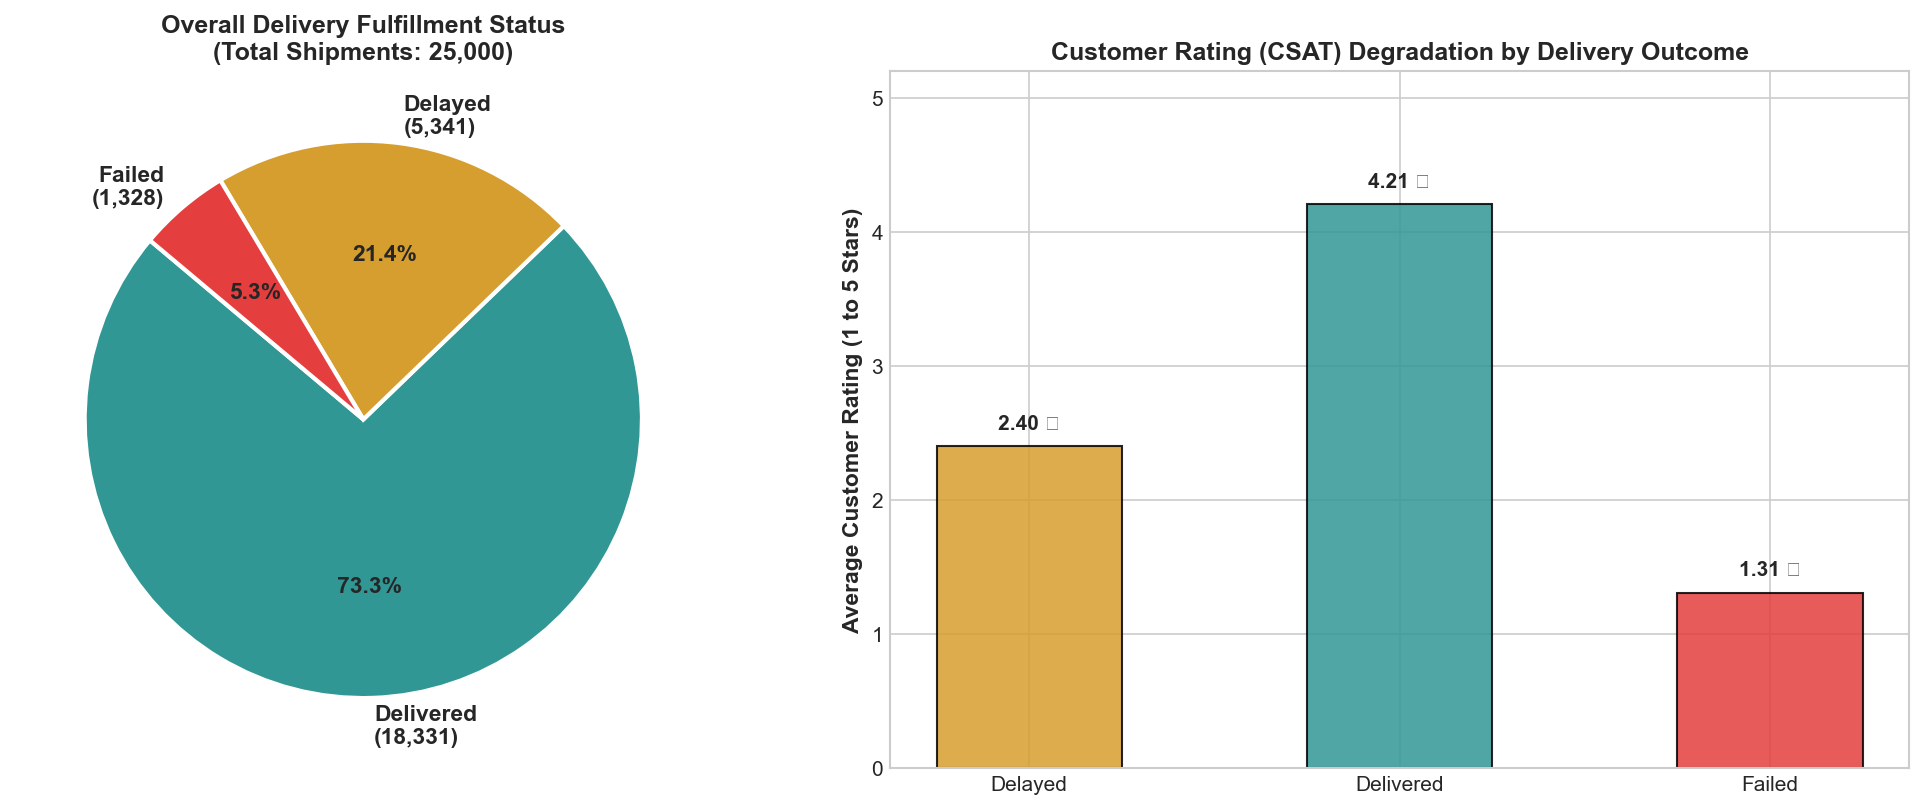

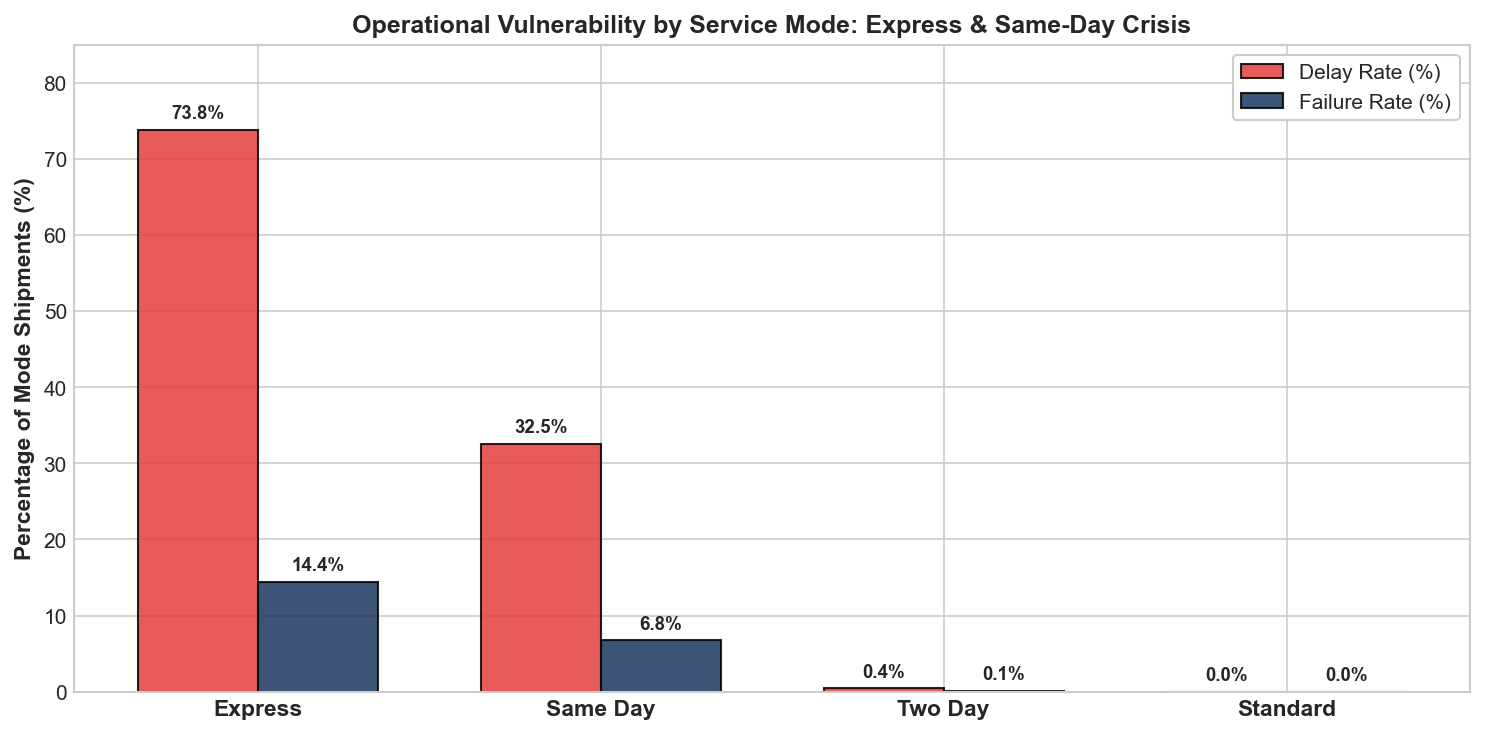

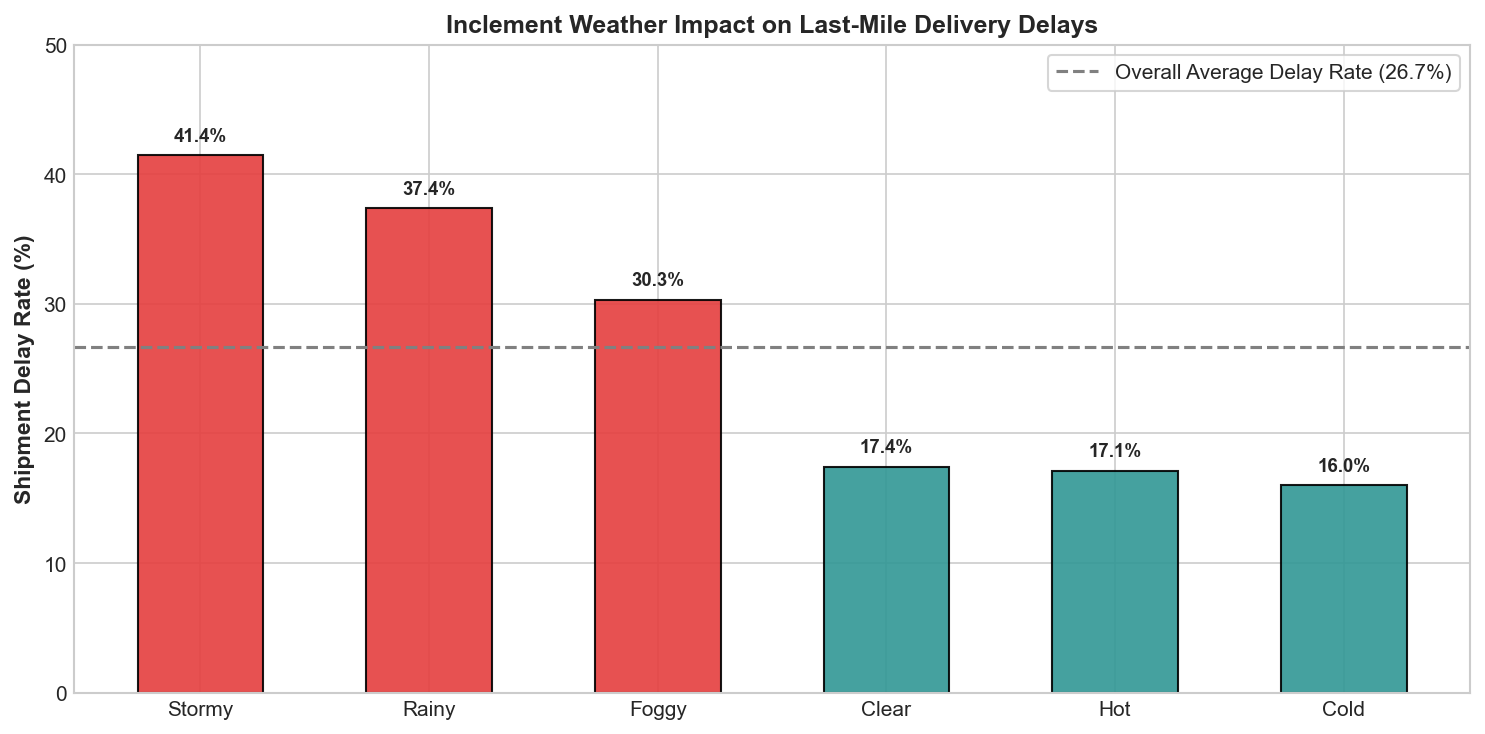

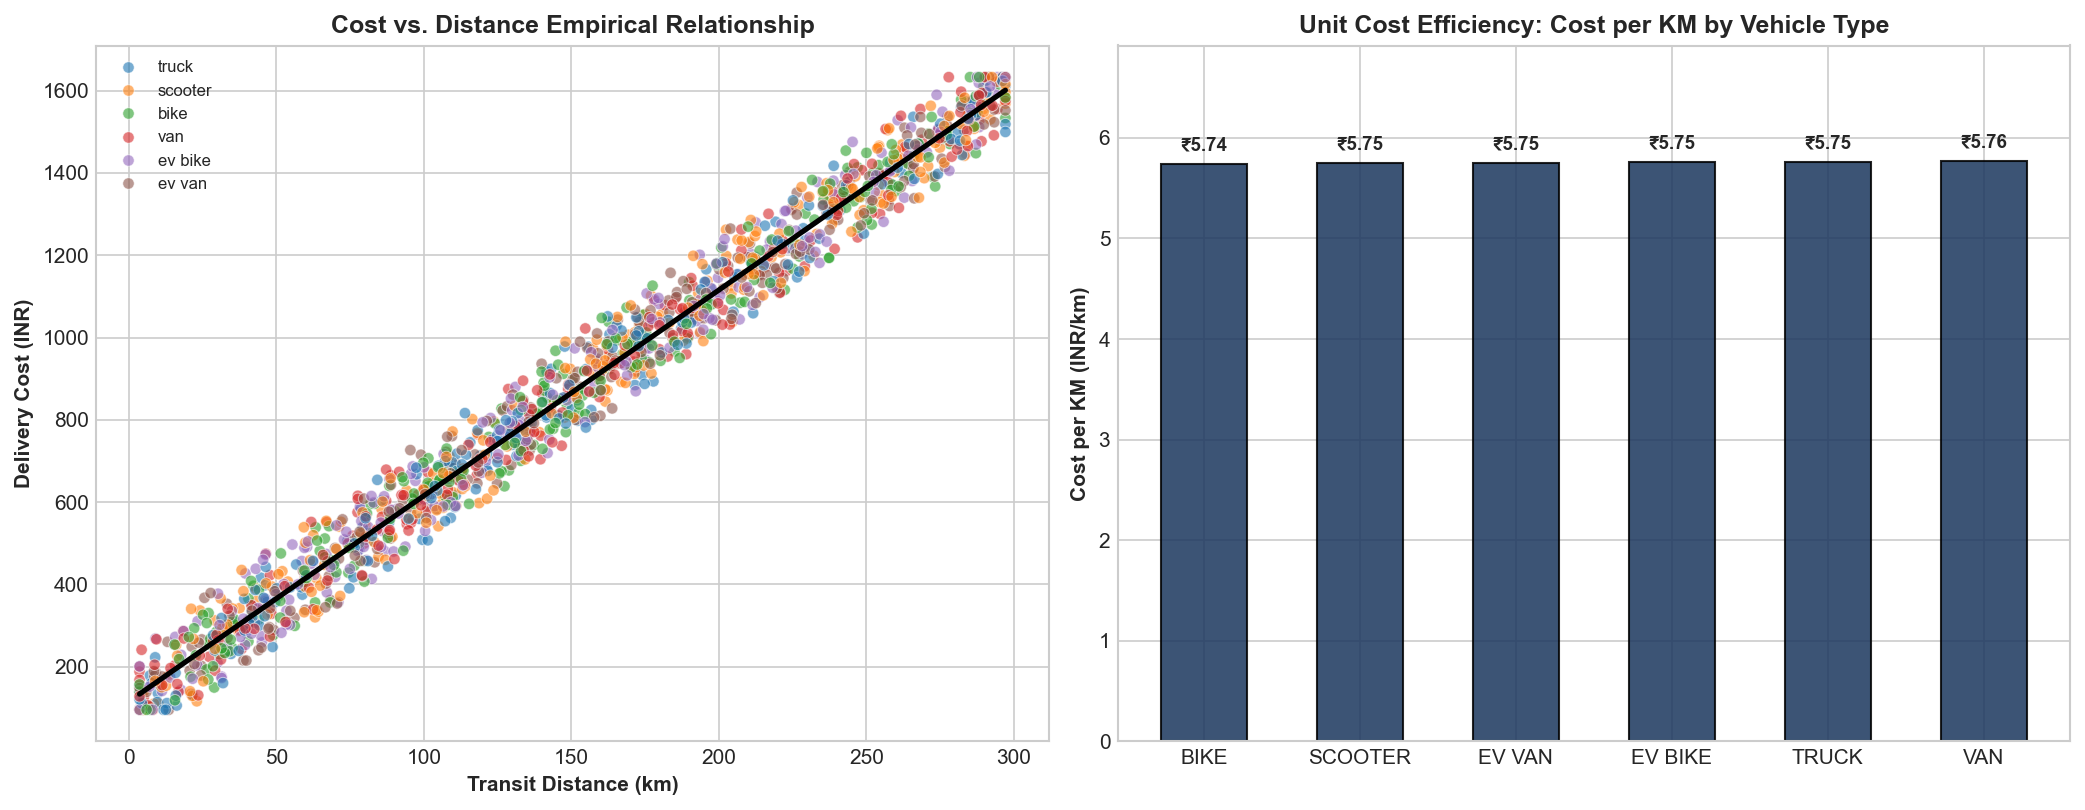

C:\Users\subha\AppData\Local\Temp\ipykernel_2320\2640258076.py:106: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\subha\AppData\Local\Programs\Python\Python314\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


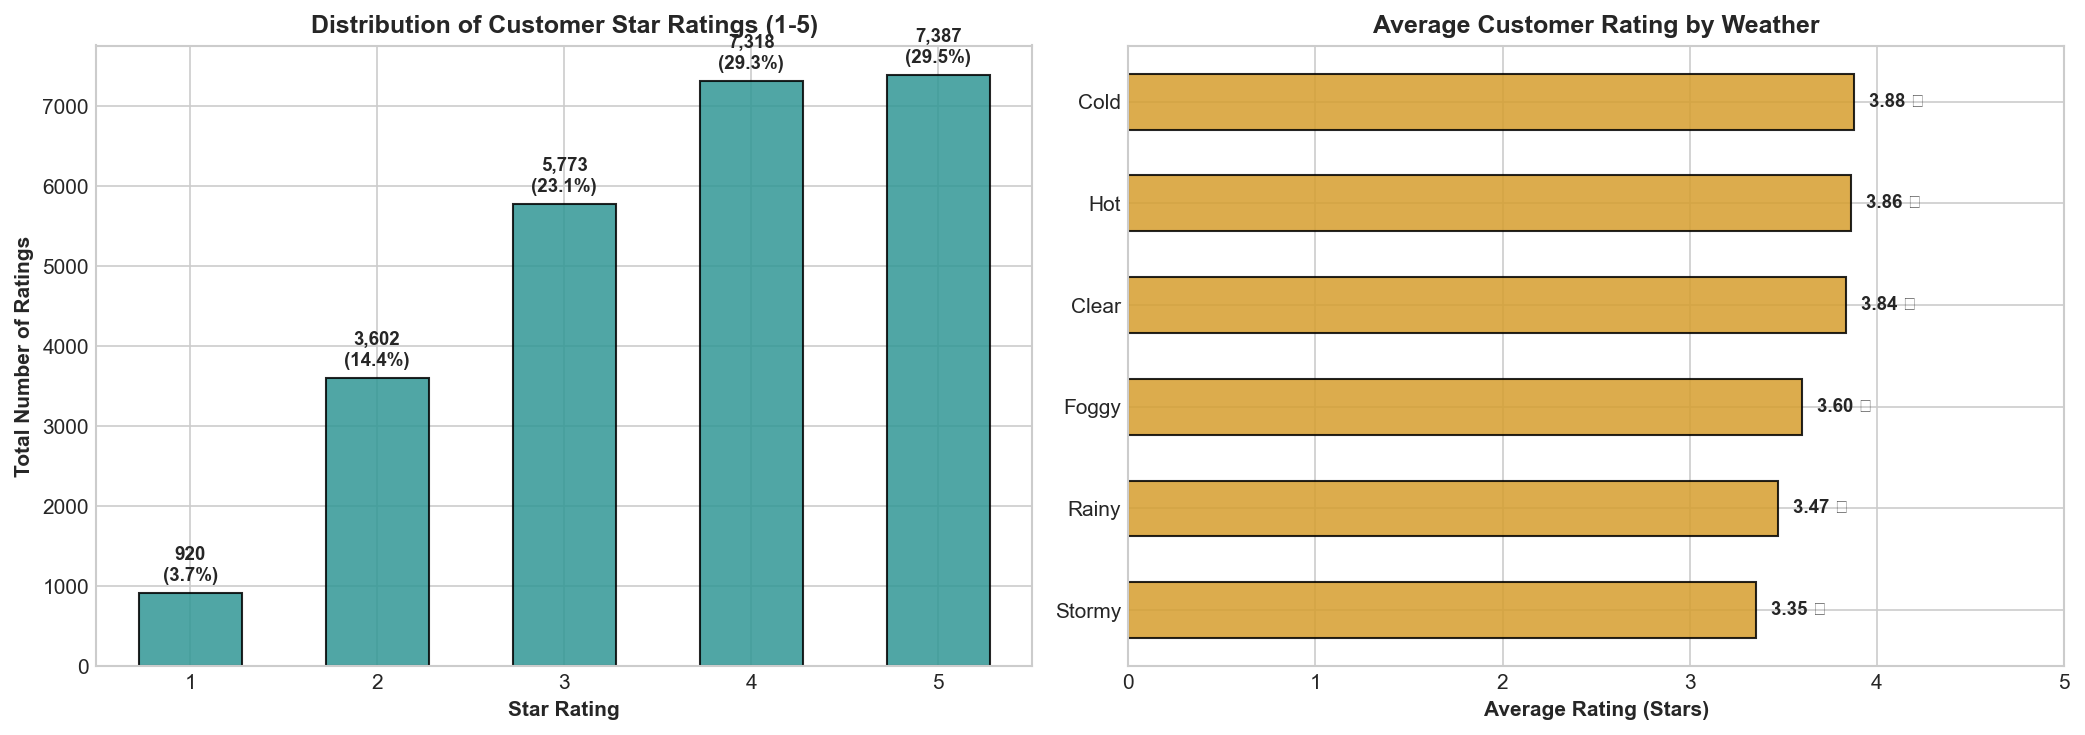

C:\Users\subha\AppData\Local\Temp\ipykernel_2320\2640258076.py:128: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()


C:\Users\subha\AppData\Local\Programs\Python\Python314\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


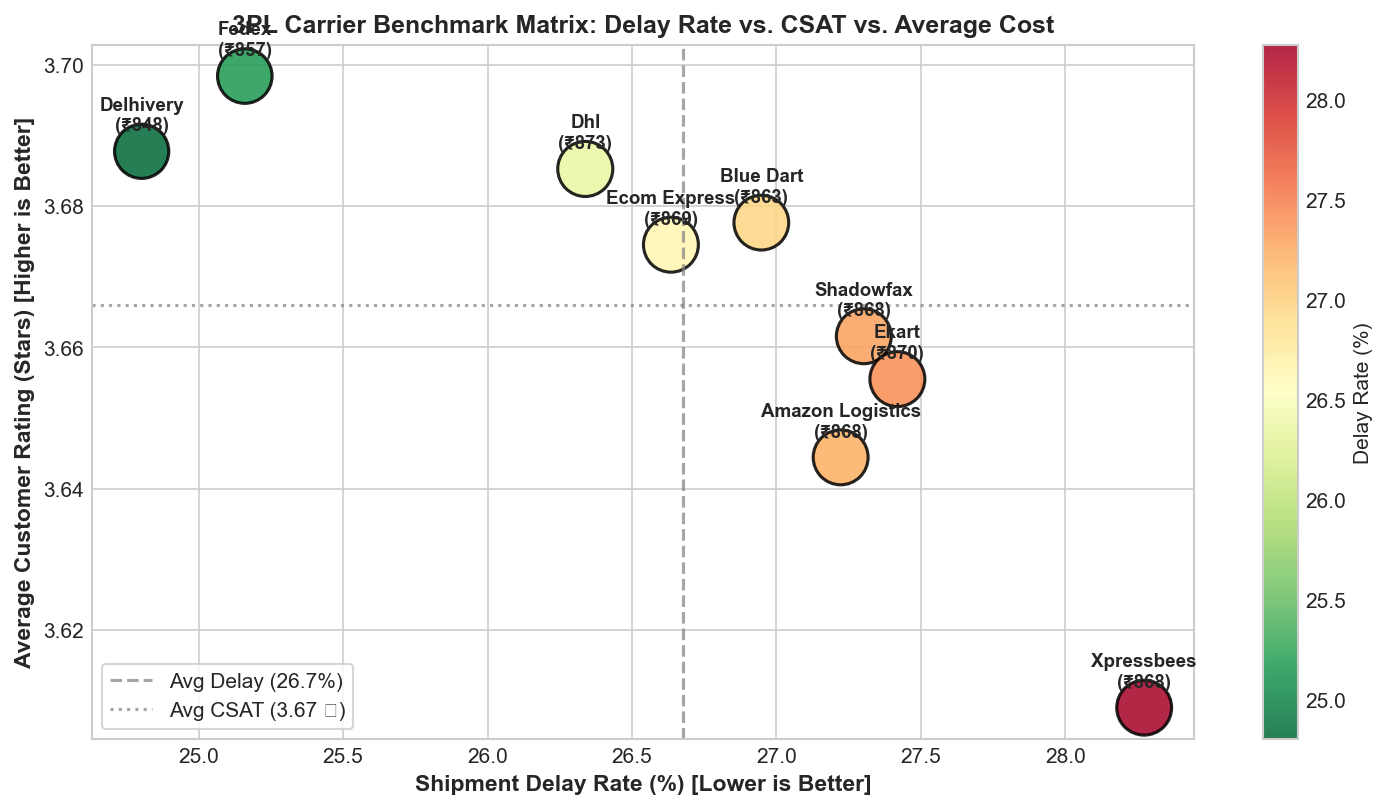

In [6]:
brand_blue = '#1A365D'
coral_red = '#E53E3E'
teal_green = '#319795'
amber_yellow = '#D69E2E'

# Figure 1: Overall Delivery Fulfillment Status & CSAT Breakdown
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
status_counts = df['delivery_status'].value_counts()
axes[0].pie(status_counts, labels=[f'{k.capitalize()}\n({v:,})' for k, v in status_counts.items()],
            autopct='%1.1f%%', startangle=140, colors=[teal_green, amber_yellow, coral_red], 
            wedgeprops={'edgecolor': 'white', 'linewidth': 2},
            textprops={'fontsize': 11, 'fontweight': 'bold'})
axes[0].set_title('Overall Delivery Fulfillment Status\n(Total Shipments: 25,000)', fontsize=12, fontweight='bold')

rating_by_status = df.groupby('delivery_status')['delivery_rating'].mean()
bar_cols = [coral_red if x == 'failed' else (amber_yellow if x == 'delayed' else teal_green) for x in rating_by_status.index]
bars = axes[1].bar([s.capitalize() for s in rating_by_status.index], rating_by_status.values, color=bar_cols, width=0.5, edgecolor='black', alpha=0.85)
axes[1].set_ylabel('Average Customer Rating (1 to 5 Stars)', fontsize=11, fontweight='bold')
axes[1].set_ylim(0, 5.2)
axes[1].set_title('Customer Rating (CSAT) Degradation by Delivery Outcome', fontsize=12, fontweight='bold')
for bar in bars:
    h = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., h + 0.1, f'{h:.2f} ★', ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

# Figure 2: Delay & Failure Rates across Delivery Service Modes
fig, ax = plt.subplots(figsize=(10, 5))
modes = mode_stats.index.str.title()
x = np.arange(len(modes))
width = 0.35
b1 = ax.bar(x - width/2, mode_stats['delay_rate'], width, label='Delay Rate (%)', color=coral_red, alpha=0.85, edgecolor='black')
b2 = ax.bar(x + width/2, mode_stats['failure_rate'], width, label='Failure Rate (%)', color=brand_blue, alpha=0.85, edgecolor='black')
ax.set_ylabel('Percentage of Mode Shipments (%)', fontsize=11, fontweight='bold')
ax.set_title('Operational Vulnerability by Service Mode: Express & Same-Day Crisis', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(modes, fontsize=11, fontweight='bold')
ax.legend(frameon=True, facecolor='white', framealpha=1)
ax.set_ylim(0, 85)
for bar in b1:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., h + 1, f'{h:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
for bar in b2:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., h + 1, f'{h:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

# Figure 3: Inclement Weather Impact
fig, ax = plt.subplots(figsize=(10, 5))
weathers = weather_stats.index.str.title()
delay_vals = weather_stats['delay_rate']
palette = [coral_red if val > 30 else (amber_yellow if val > 20 else teal_green) for val in delay_vals]
bars = ax.bar(weathers, delay_vals, color=palette, width=0.55, edgecolor='black', alpha=0.9)
ax.axhline(df['delayed'].eq('yes').mean() * 100, color='grey', linestyle='--', linewidth=1.5, label='Overall Average Delay Rate (26.7%)')
ax.set_ylabel('Shipment Delay Rate (%)', fontsize=11, fontweight='bold')
ax.set_title('Inclement Weather Impact on Last-Mile Delivery Delays', fontsize=12, fontweight='bold')
ax.set_ylim(0, 50)
ax.legend(loc='upper right', frameon=True)
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., h + 0.8, f'{h:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

# Figure 4: Cost vs. Distance Regression & Unit Cost per KM
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
sample_df = df.sample(n=1500, random_state=42)
sns.scatterplot(data=sample_df, x='distance_km', y='delivery_cost', hue='vehicle_type', 
                alpha=0.6, s=30, ax=axes[0], palette='tab10')
sns.regplot(data=sample_df, x='distance_km', y='delivery_cost', scatter=False, ax=axes[0], color='black', 
            line_kws={'linewidth': 2.5, 'label': 'Linear Fit (R²=0.98)'})
axes[0].set_title('Cost vs. Distance Empirical Relationship', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Transit Distance (km)', fontsize=10, fontweight='bold')
axes[0].set_ylabel('Delivery Cost (INR)', fontsize=10, fontweight='bold')
axes[0].legend(fontsize=8)

v_stats = df.groupby('vehicle_type').apply(lambda g: g['delivery_cost'].sum() / g['distance_km'].sum()).sort_values()
v_bars = axes[1].bar([v.upper() for v in v_stats.index], v_stats.values, color=brand_blue, width=0.55, edgecolor='black', alpha=0.85)
axes[1].set_title('Unit Cost Efficiency: Cost per KM by Vehicle Type', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Cost per KM (INR/km)', fontsize=10, fontweight='bold')
axes[1].set_ylim(0, max(v_stats.values) * 1.2)
for bar in v_bars:
    h = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., h + 0.1, f'₹{h:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

# Figure 5: Customer Rating Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
rating_counts = df['delivery_rating'].value_counts().sort_index()
axes[0].bar(rating_counts.index, rating_counts.values, color=teal_green, width=0.55, edgecolor='black', alpha=0.85)
axes[0].set_title('Distribution of Customer Star Ratings (1-5)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Star Rating', fontsize=10, fontweight='bold')
axes[0].set_ylabel('Total Number of Ratings', fontsize=10, fontweight='bold')
for x_val, y_val in zip(rating_counts.index, rating_counts.values):
    axes[0].text(x_val, y_val + 100, f'{y_val:,}\n({y_val/len(df):.1%})', ha='center', va='bottom', fontsize=9, fontweight='bold')

rw = df.groupby('weather_condition')['delivery_rating'].mean().sort_values()
axes[1].barh(rw.index.str.title(), rw.values, color=amber_yellow, height=0.55, edgecolor='black', alpha=0.85)
axes[1].set_title('Average Customer Rating by Weather', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Average Rating (Stars)', fontsize=10, fontweight='bold')
axes[1].set_xlim(0, 5)
for i, v in enumerate(rw.values):
    axes[1].text(v + 0.08, i, f'{v:.2f} ★', va='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

# Figure 6: 3PL Partner Benchmark Matrix
fig, ax = plt.subplots(figsize=(10, 5.5))
carriers = partner_stats.index.str.title()
delay_rates = partner_stats['delay_rate']
ratings = partner_stats['avg_rating']
costs = partner_stats['avg_cost']

scatter = ax.scatter(delay_rates, ratings, s=costs*0.8, c=delay_rates, cmap='RdYlGn_r', 
                     edgecolors='black', linewidth=1.5, alpha=0.85)
for i, txt in enumerate(carriers):
    ax.annotate(f'{txt}\n(₹{costs.iloc[i]:.0f})', (delay_rates.iloc[i], ratings.iloc[i]),
                xytext=(0, 10), textcoords='offset points', ha='center', fontsize=9, fontweight='bold')
ax.axvline(delay_rates.mean(), color='grey', linestyle='--', alpha=0.7, label=f'Avg Delay ({delay_rates.mean():.1f}%)')
ax.axhline(ratings.mean(), color='grey', linestyle=':', alpha=0.7, label=f'Avg CSAT ({ratings.mean():.2f} ★)')
ax.set_xlabel('Shipment Delay Rate (%) [Lower is Better]', fontsize=11, fontweight='bold')
ax.set_ylabel('Average Customer Rating (Stars) [Higher is Better]', fontsize=11, fontweight='bold')
ax.set_title('3PL Carrier Benchmark Matrix: Delay Rate vs. CSAT vs. Average Cost', fontsize=12, fontweight='bold')
ax.legend(loc='lower left', frameon=True)
plt.colorbar(scatter, ax=ax, label='Delay Rate (%)')
plt.tight_layout()
plt.show()


## Stage 6: Strategic Recommendations
1. **Dynamic SLA Buffering**: Restrict fixed Express promises on routes exceeding 200 km or during adverse weather.
2. **Weather-Adaptive Dispatch**: Integrate real-time weather feeds to add 4-6 hour delivery buffers during stormy/rainy conditions.
3. **Carrier Volume Reallocation**: Prioritize top-tier partners (Delhivery, FedEx) and penalize lagging carriers (Xpressbees) exceeding 5% failure thresholds.
4. **Targeted Fleet Electrification**: Accelerate EV bike and EV van deployment in dense urban hubs where EV unit costs match combustion vehicles (₹5.75/km).
